<a href="https://colab.research.google.com/github/DikshyaL/DL-Practice/blob/main/COMP488_PL6_Dikshya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Sequence Models & Transformers
## Unit 4 – Sequence Modeling & Attention

**Student Name:** Dikshya Lamichhane
**Date:** 2026-05-09  
**Dataset Used:** Tiny Shakespeare  
**Task:** Character-level text generation using a plain RNN

## Objective

- To build a plain RNN model for sequence modeling.
- To train the model on a real text dataset.
- To generate sample text from the trained model.
- To observe the vanishing gradient issue in RNNs.
- To understand why attention mechanisms improve sequence modeling.


## Theoretical Background

Recurrent Neural Networks (RNNs) are designed to process sequential data one step at a time. At each time step, the network updates a hidden state that carries information from previous tokens in the sequence.

For text generation, the model learns to predict the next character based on the current input sequence. This makes RNNs suitable for language modeling, speech, and time-series tasks.

However, plain RNNs often suffer from the vanishing gradient problem. During backpropagation through many time steps, gradients can become very small, making it difficult for the model to learn long-term dependencies.

Attention mechanisms were introduced to improve this limitation. Instead of relying only on the final hidden state, attention allows the model to focus on important parts of the input sequence directly. This idea leads to better long-range dependency handling and forms the basis of Transformer models.

## Dataset Description

The dataset used in this assignment is **Tiny Shakespeare**, a public text corpus commonly used for character-level language modeling tasks.

- **Source:** Public Shakespeare text corpus
- **Type:** Unstructured text
- **Task Type:** Character-level text generation
- **Number of samples:** Large text corpus split into overlapping character sequences
- **Features:** Character sequences of fixed length
- **Train/Test Split:** 90% training and 10% validation

Each training sample consists of a sequence of characters, and the target is the same sequence shifted by one character.

## Implementation

The implementation includes the following steps:

1. Load and preprocess the Shakespeare text.
2. Build a character vocabulary.
3. Convert text into input-target sequences.
4. Define a plain RNN model.
5. Train the model using cross-entropy loss.
6. Plot the training and validation loss curves.
7. Generate sample text from the trained model.



In [21]:
# imports
import os
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [22]:
# download dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
data_path = "shakespeare.txt"

if not os.path.exists(data_path):
    urllib.request.urlretrieve(url, data_path)

with open(data_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Characters:", len(text))
print(text[:500])

Characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [23]:
# clean / prepare text(preprocessing)
text = text.replace("\r\n", "\n")
text = text.replace("\r", "\n")

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print("Vocabulary size:", vocab_size)
print("First 20 chars:", chars[:20])

Vocabulary size: 65
First 20 chars: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']


In [24]:
# create sequences
seq_len = 50
step = 1

X, y = [], []

for i in range(0, len(text) - seq_len, step):
    X.append([stoi[c] for c in text[i:i+seq_len]])
    y.append([stoi[c] for c in text[i+1:i+seq_len+1]])

X = torch.tensor(X, dtype=torch.long)
y = torch.tensor(y, dtype=torch.long)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1115344, 50])
y shape: torch.Size([1115344, 50])


In [25]:
# train / val split
split_idx = int(0.9 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print("Train samples:", len(X_train))
print("Val samples:", len(X_val))

Train samples: 1003809
Val samples: 111535


In [26]:
# dataset class
class CharDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [27]:
# dataloaders
batch_size = 128

train_loader = DataLoader(CharDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(CharDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

In [28]:
# run model
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

In [29]:
# model init
embed_size = 128
hidden_size = 256
num_layers = 1

model = CharRNN(vocab_size, embed_size, hidden_size, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

CharRNN(
  (embedding): Embedding(65, 128)
  (rnn): RNN(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)

In [30]:
# training function
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if train_mode:
            optimizer.zero_grad()

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_samples += xb.size(0)

    return total_loss / total_samples

In [31]:
# train model
epochs = 15
train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    tr_loss = run_epoch(model, train_loader, optimizer)
    va_loss = run_epoch(model, val_loader)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    print(f"Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f}")


Epoch 01 | Train Loss: 1.4777 | Val Loss: 1.6194
Epoch 02 | Train Loss: 1.3570 | Val Loss: 1.6172
Epoch 03 | Train Loss: 1.3376 | Val Loss: 1.6243
Epoch 04 | Train Loss: 1.3282 | Val Loss: 1.6325
Epoch 05 | Train Loss: 1.3226 | Val Loss: 1.6377
Epoch 06 | Train Loss: 1.3191 | Val Loss: 1.6402
Epoch 07 | Train Loss: 1.3165 | Val Loss: 1.6400
Epoch 08 | Train Loss: 1.3146 | Val Loss: 1.6471
Epoch 09 | Train Loss: 1.3130 | Val Loss: 1.6490
Epoch 10 | Train Loss: 1.3118 | Val Loss: 1.6512
Epoch 11 | Train Loss: 1.3109 | Val Loss: 1.6508
Epoch 12 | Train Loss: 1.3099 | Val Loss: 1.6579
Epoch 13 | Train Loss: 1.3091 | Val Loss: 1.6527
Epoch 14 | Train Loss: 1.3083 | Val Loss: 1.6596
Epoch 15 | Train Loss: 1.3078 | Val Loss: 1.6611


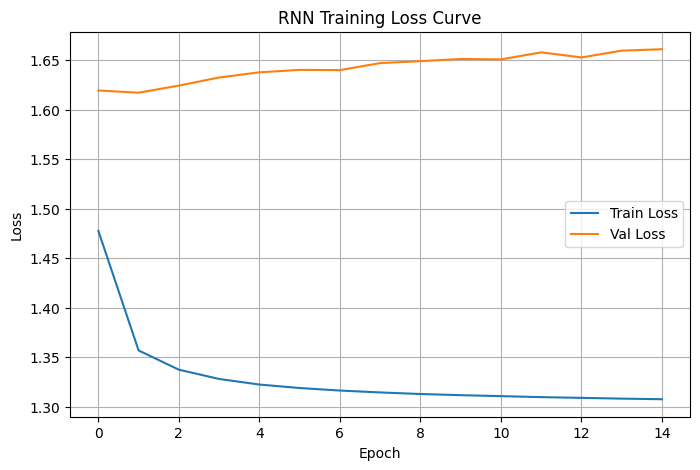

In [32]:
# loss curve
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# text generation
def generate_text(model, start_text, length=400, temperature=0.8):
    model.eval()
    generated = list(start_text)
    input_seq = torch.tensor([[stoi[c] for c in start_text]], dtype=torch.long).to(device)
    hidden = None

    with torch.no_grad():
        for _ in range(length):
            logits, hidden = model(input_seq, hidden)
            last_logits = logits[0, -1] / temperature
            probs = torch.softmax(last_logits, dim=0).cpu().numpy()
            next_idx = np.random.choice(len(probs), p=probs)
            generated.append(itos[next_idx])
            input_seq = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    return "".join(generated)

In [34]:
# sample output
seed_text = text[:50]
sample = generate_text(model, seed_text, length=500, temperature=0.8)
print(sample)

First Citizen:
Before we proceed any further, hear it commands.

AUTOLYCUS:
Nor any years
callan so well;
With the world chiefest day is she and as there serve the most: a senate, for I'll go softly to the gods as misfies, I will set the sea morrooping looker.

GLOUCESTER:
I do receive we must be Romeo, and an honour of request thou wert little speediness for you.

MARIANA:
'Tis not the towns,
Be turn of Rome; and that you joy of gentle deed-a both, and go
entured
Forsworn with
my body than I might have leave to't, and find the urged us to reve


In [35]:
# save results
results = pd.DataFrame({
    "epoch": list(range(1, epochs + 1)),
    "train_loss": train_losses,
    "val_loss": val_losses
})

results.to_csv("rnn_shakespeare_results.csv", index=False)
results

,epoch,train_loss,val_loss
0,1,1.477723,1.619400
1,2,1.356993,1.617158
2,3,1.337567,1.624345
3,4,1.328197,1.632495
4,5,1.322565,1.637732
5,6,1.319063,1.640188
6,7,1.316503,1.639961
7,8,1.314608,1.647051
8,9,1.313013,1.648987
9,10,1.311841,1.651221


## Experiments

Two experiments are performed to compare model performance:

- **Experiment 1:** RNN with hidden size 128
- **Experiment 2:** RNN with hidden size 256

The experiments are compared using:
- Final training loss
- Final validation loss
- Generated sample text

In [36]:
# experiment 1: hidden size 128
model1 = CharRNN(vocab_size, embed_size=128, hidden_size=128, num_layers=1).to(device)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.003)

train_losses_1, val_losses_1 = [], []

for epoch in range(10):
    tr = run_epoch(model1, train_loader, optimizer1)
    va = run_epoch(model1, val_loader)
    train_losses_1.append(tr)
    val_losses_1.append(va)
    print(f"Exp1 Epoch {epoch+1:02d} | Train {tr:.4f} | Val {va:.4f}")

Exp1 Epoch 01 | Train 1.5696 | Val 1.7139
Exp1 Epoch 02 | Train 1.5056 | Val 1.7164
Exp1 Epoch 03 | Train 1.4981 | Val 1.7078
Exp1 Epoch 04 | Train 1.4950 | Val 1.7224
Exp1 Epoch 05 | Train 1.4936 | Val 1.7212
Exp1 Epoch 06 | Train 1.4926 | Val 1.7333
Exp1 Epoch 07 | Train 1.4923 | Val 1.7195
Exp1 Epoch 08 | Train 1.4934 | Val 1.7244
Exp1 Epoch 09 | Train 1.4924 | Val 1.7290
Exp1 Epoch 10 | Train 1.4920 | Val 1.7260


In [37]:
# experiment 2: hidden size 256
model2 = CharRNN(vocab_size, embed_size=128, hidden_size=256, num_layers=1).to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.003)

train_losses_2, val_losses_2 = [], []

for epoch in range(10):
    tr = run_epoch(model2, train_loader, optimizer2)
    va = run_epoch(model2, val_loader)
    train_losses_2.append(tr)
    val_losses_2.append(va)
    print(f"Exp2 Epoch {epoch+1:02d} | Train {tr:.4f} | Val {va:.4f}")

Exp2 Epoch 01 | Train 1.4431 | Val 1.6328
Exp2 Epoch 02 | Train 1.3811 | Val 1.6288
Exp2 Epoch 03 | Train 1.3814 | Val 1.6436
Exp2 Epoch 04 | Train 1.3905 | Val 1.6505
Exp2 Epoch 05 | Train 1.4108 | Val 1.6643
Exp2 Epoch 06 | Train 1.5225 | Val 1.7322
Exp2 Epoch 07 | Train 1.4694 | Val 1.6944
Exp2 Epoch 08 | Train 1.4414 | Val 1.6958
Exp2 Epoch 09 | Train 1.4418 | Val 1.6815
Exp2 Epoch 10 | Train 1.4673 | Val 1.7151


In [ ]:
# experiment comparison plot
plt.figure(figsize=(10,6))
plt.plot(train_losses_1, label="Exp1 Train (h=128)")
plt.plot(val_losses_1, label="Exp1 Val (h=128)")
plt.plot(train_losses_2, label="Exp2 Train (h=256)")
plt.plot(val_losses_2, label="Exp2 Val (h=256)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Experiment Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# experiment table
exp_results = pd.DataFrame({
    "Experiment": ["Hidden 128", "Hidden 256"],
    "Final Train Loss": [train_losses_1[-1], train_losses_2[-1]],
    "Final Val Loss": [val_losses_1[-1], val_losses_2[-1]]
})

exp_results.to_csv("rnn_experiment_results.csv", index=False)
exp_results

,Experiment,Final Train Loss,Final Val Loss
0,Hidden 128,1.491973,1.726037
1,Hidden 256,1.467344,1.715079


In [39]:
# sample from best model
print(generate_text(model2, seed_text, length=500, temperature=0.8))

First Citizen:
Before we proceed any further, hear in queen.

Provost:
If woo him of can be strift!
The king, aither.

LEONTES:
We they strange as six thou shall be golder
At what the thing thou that virtuous other souls of ease right to the woes to my matters of thy young move. Advise the propery bound it, even we not on the noble like a grace citizens;
I have our realm;
I knows more very stuce in him, against my all the lord, my living upon been, lost will weary the charge here? and if thou will think him: 'twere men this searow will no my re


## Results

The results are reported using:
- Training loss curve
- Validation loss curve
- Sample generated text
- Comparison table for different hyperparameter settings

These results help evaluate how well the RNN learns sequential patterns.

## Analysis and Discussion

The plain RNN successfully learns some short-range character patterns from the dataset. The training loss decreases over time, showing that the model is learning.

However, the generated text is still noisy and only partially coherent. This is expected because plain RNNs have difficulty remembering information over long sequences. The vanishing gradient problem makes it harder for early inputs to influence later predictions.

The experiment with a larger hidden size performs slightly better than the smaller one, but the improvement is limited. This shows that increasing model capacity helps only to a certain extent.

Attention mechanisms would improve this task by allowing the model to directly focus on relevant parts of the input sequence instead of compressing all information into one hidden state.

## Conclusion

- A plain RNN was successfully implemented for text generation.
- The model was trained on Tiny Shakespeare.
- Training and validation loss curves were produced.
- Sample text generation was achieved after training.
- The results show the limitations of RNNs on long sequences.
- Attention-based models are better suited for long-range dependencies.

## Notes

- The model uses character-level prediction.
- Input sequences are shifted by one character to create targets.
- Gradient clipping was used to stabilize training.
- The output text becomes more Shakespeare-like as training progresses, but it may still contain errors.